In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier#, RandomForestRegressor
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

In [2]:
data = pd.read_parquet('../data/interim/meteorological_data_with_outages.parquet')

In [3]:
data.columns
#data['outage_in_an_hour'] = (data['hours_to_outage']<=1).astype(int)
data['outage_in_an_hour'].mean()

np.float64(0.027549734662457963)

In [4]:
train_episode_fips_id, test_episode_fips_id = train_test_split(
    data.episode_fips_id.unique(), 
    train_size=0.7, 
    random_state=42
)

In [5]:
drop_cols = ['time', 'episode_fips_id', 'meteorological_current_datetime_val', 'hours_to_outage']
#drop_cols = ['time', 'episode_fips_id', 'meteorological_current_datetime_val', 'outage_in_an_hour']

data_train = data[data.episode_fips_id.isin(train_episode_fips_id)].drop(drop_cols, axis=1)
data_test = data[data.episode_fips_id.isin(test_episode_fips_id)].drop(drop_cols, axis=1)

In [6]:
x_train, y_train = data_train.drop('outage_in_an_hour', axis=1), data_train.outage_in_an_hour
x_test, y_test = data_test.drop('outage_in_an_hour', axis=1), data_test.outage_in_an_hour

#x_train, y_train = data_train.drop('hours_to_outage', axis=1), data_train.hours_to_outage
#x_test, y_test = data_test.drop('hours_to_outage', axis=1), data_test.hours_to_outage

In [7]:
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced',
    ccp_alpha=0.001, 
)

#model = RandomForestRegressor(
#    n_estimators=100, 
#    max_depth=12, 
#    #class_weight='balanced',
#    ccp_alpha=0.001, 
#)

In [8]:
model.fit(x_train, y_train)

RandomForestClassifier(ccp_alpha=0.001, class_weight='balanced', max_depth=12)

In [9]:
#pred_train = pd.Series(model.predict(x_train))
#pred_train.index = x_train.index

In [10]:
pred_train = pd.Series(model.predict_proba(x_train)[:, 1])
pred_train.index = x_train.index

In [11]:
#pred_test = pd.Series(model.predict(x_test))
#pred_test.index = x_test.index

In [12]:
pred_test = pd.Series(model.predict_proba(x_test)[:, 1])
pred_test.index = x_test.index

In [13]:
#from sklearn.metrics import r2_score
#r2_score(y_train, pred_train), r2_score(y_test, pred_test)


In [14]:
roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_test)

(np.float64(0.78786262235925), np.float64(0.7731789927055643))

In [15]:
roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_test)

(np.float64(0.8084444638039983), np.float64(0.7898080061659394))

In [15]:
precision, recall, _ = precision_recall_curve(y_test, pred_test)
auc(recall, precision)

np.float64(0.0969070703181878)

In [16]:
precision, recall, _ = precision_recall_curve(y_train, pred_train)
auc(recall, precision)

np.float64(0.10403249528143663)

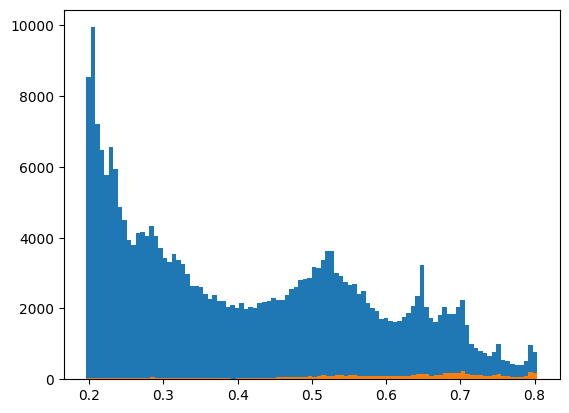

In [17]:
plt.hist(pred_test[y_test==0], bins=100)
plt.hist(pred_test[y_test==1],bins=100)
plt.show()

In [18]:
response_var = pd.read_parquet('../data/interim/storm_outages_2014_2023.parquet')

/tmp/ipykernel_27627/3604526345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data['pred'] = pred_train


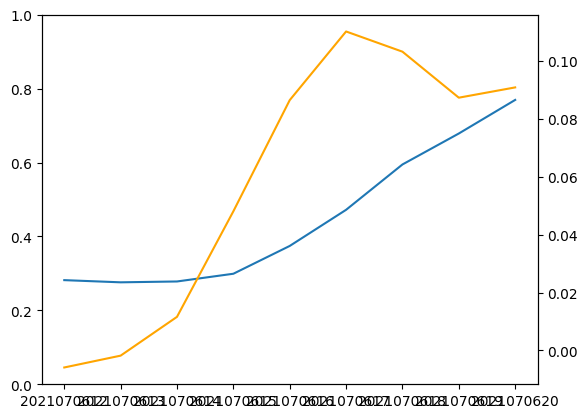

In [21]:
import numpy as np
sample_id = pd.Series(train_episode_fips_id).sample(1).iloc[0]
sample_data = data[data.episode_fips_id==sample_id]
sample_data['pred'] = pred_train
plt.plot(sample_data.time, sample_data.pred)
plt.ylim(0,1)
fig = plt.gcf()
ax = fig.axes[0]
ax2 = ax.twinx()
ax2.plot(sample_data.time, np.gradient(sample_data.pred), color='orange')
